<a href="https://colab.research.google.com/github/MoazMorsh/Fitness-Class-Attendance-ML-Classification-Models/blob/main/Fitness_Class_Attendance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitness Class Attendance

### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Read CSV File

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [57]:
# Set the path to the file you'd like to load
file_path = "fitness_class_2212.csv"

# Load the latest version
data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ddosad/datacamps-data-science-associate-certification",
  file_path,
)

Using Colab cache for faster access to the 'datacamps-data-science-associate-certification' dataset.


### Display Data for Understanding the Columns

In [4]:
# Show the first n-records
data.head()

,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0


In [5]:
# Show the number of rows and coulmns in the dataset
data.shape

(1500, 8)

In [6]:
# Show a detailed information about the attributes in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        1500 non-null   int64  
 1   months_as_member  1500 non-null   int64  
 2   weight            1480 non-null   float64
 3   days_before       1500 non-null   object 
 4   day_of_week       1500 non-null   object 
 5   time              1500 non-null   object 
 6   category          1500 non-null   object 
 7   attended          1500 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 93.9+ KB


### Exploratory Data Analysis

#### Drop Unnecessary Columns

In [7]:
data = data.drop("booking_id", axis=1)

#### Display the unique values for each attribute

In [8]:
# Unique values for "months_as_member" column
data.months_as_member.unique()
# This attribute has no problem as the unique values are numbers and the data type is intger

array([ 17,  10,  16,   5,  15,   7,  11,   9,  23,  13,   8,  22,   6,
        33,  24,  14,   2,  12,  26,  28,  27,   1,   3,  21,  18,  19,
        53,  20,  34,  25,  32,  73,  55,   4,  35,  54,  76,  62,  42,
       105,  90,  29,  60,  30, 107,  52,  37,  38,  48,  51,  40,  89,
        57,  36,  44,  39,  41,  47,  58,  66,  45,  43,  61,  50,  65,
        31,  97,  59,  93, 148, 111,  69])

In [9]:
# Unique values for "days_before" column
data.days_before.unique()
# Some values has the word "days" after the number which makes the column object instead of intger

array(['8', '2', '14', '10', '6', '4', '9', '12', '5', '3', '7', '13',
       '12 days', '20', '1', '15', '6 days', '11', '13 days', '3 days',
       '16', '1 days', '7 days', '8 days', '10 days', '14 days', '17',
       '5 days', '2 days', '4 days', '29'], dtype=object)

In [10]:
# Drop the word "days" from "days_before" column
data['days_before'] = data['days_before'].str.replace(' days', '').astype(int)

In [11]:
# Double check for unique values for "days_before" column after adjustments
data.days_before.unique()

array([ 8,  2, 14, 10,  6,  4,  9, 12,  5,  3,  7, 13, 20,  1, 15, 11, 16,
       17, 29])

In [12]:
# Unique values for "day_of_week" column
data.day_of_week.unique()
# The column contains values with abbreviation and the other with full word, So we need to fix it

array(['Wed', 'Mon', 'Sun', 'Fri', 'Thu', 'Wednesday', 'Fri.', 'Tue',
       'Sat', 'Monday'], dtype=object)

In [13]:
# Fix Values in "day_of_week" column
data['day_of_week'] = data['day_of_week'].str[:3]

In [14]:
# Display "day_of_week" after adjustments
data.day_of_week.unique()

array(['Wed', 'Mon', 'Sun', 'Fri', 'Thu', 'Tue', 'Sat'], dtype=object)

In [15]:
# Unique values for "time" column
data.time.unique()
# The column is okay no need for adjustments

array(['PM', 'AM'], dtype=object)

In [16]:
# Mapping the values of the "time" column

# Making the column value upper case
data['time'] = data['time'].astype(str).str.strip().str.upper()

# 0 for "AM" and 1 for "PM"
time_mapping = {
    'AM' : 0,
    'PM' : 1,
}
data['time'] = data['time'].map(time_mapping)

In [17]:
data['time'] = data['time'].astype(int)
data.time.unique()

array([1, 0])

In [18]:
# Unique values for "category" column
data.category.unique()
# There are records with "-" that need to replaced with "unknown"

array(['Strength', 'HIIT', 'Cycling', 'Yoga', '-', 'Aqua'], dtype=object)

In [19]:
# Replace the Records conatains "-" with "unknown"
data['category'] = data['category'].str.replace("-", "unknown")

In [20]:
# Check for the "category" column after adjustmenst
data.category.unique()

array(['Strength', 'HIIT', 'Cycling', 'Yoga', 'unknown', 'Aqua'],
      dtype=object)

In [21]:
# Unique values for "attended" column
data.attended.unique()
# The column is a binary column no need for adjustments

array([0, 1])

In [22]:
# Show the values counts for each one in "attended" column
data.attended.value_counts()

,count
attended,
0,1046
1,454


#### Handle Null Values

In [23]:
# Sum of nulls in each column
data.isnull().sum()

,0
months_as_member,0
weight,20
days_before,0
day_of_week,0
time,0
category,0
attended,0


In [24]:
# Fix Nulls in "weight" column by imputing median
# data['weight'] = data['weight'].fillna(data['weight'].median())

In [25]:
# Double check for null
# data.isnull().sum()

#### Check for Duplicates

In [26]:
# Display the sum of duplicated if found
data.duplicated().sum()
# There are 1 duplicated record

np.int64(1)

#### Data Description and Statistics

In [27]:
# Display the information of the data for the last time "to double check"
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   months_as_member  1500 non-null   int64  
 1   weight            1480 non-null   float64
 2   days_before       1500 non-null   int64  
 3   day_of_week       1500 non-null   object 
 4   time              1500 non-null   int64  
 5   category          1500 non-null   object 
 6   attended          1500 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 82.2+ KB


In [28]:
# Display some descriptive statistics for the data
data.describe()

,months_as_member,weight,days_before,time,attended
count,1500.000000,1480.000000,1500.000000,1500.000000,1500.000000
mean,15.628667,82.610378,8.346667,0.239333,0.302667
std,12.926543,12.765859,4.077938,0.426819,0.459565
min,1.000000,55.410000,1.000000,0.000000,0.000000
25%,8.000000,73.490000,4.000000,0.000000,0.000000
50%,12.000000,80.760000,9.000000,0.000000,0.000000
75%,19.000000,89.520000,12.000000,0.000000,1.000000
max,148.000000,170.520000,29.000000,1.000000,1.000000


#### Check for Outliers

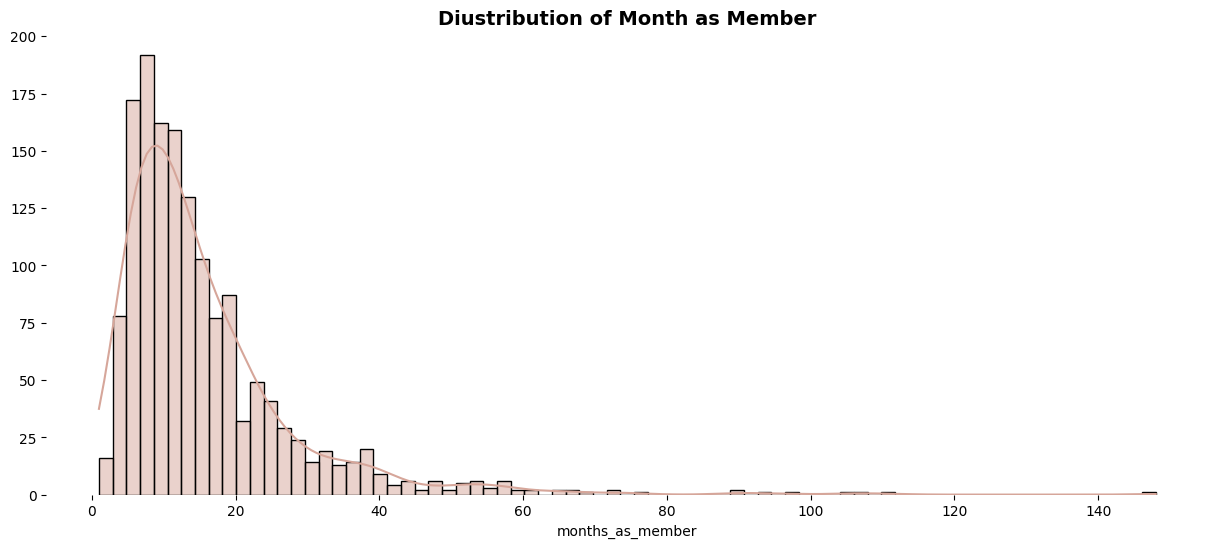

In [29]:
# Show if there outliers or not by a graph
plt.figure(figsize=(15, 6))
sns.histplot(data=data, x='months_as_member', kde=True, color="#d6a69a")
plt.xlabel('months_as_member')
plt.ylabel("")
plt.title('Diustribution of Month as Member', size=14, weight="bold")
sns.despine(left=True, bottom=True)
plt.show()

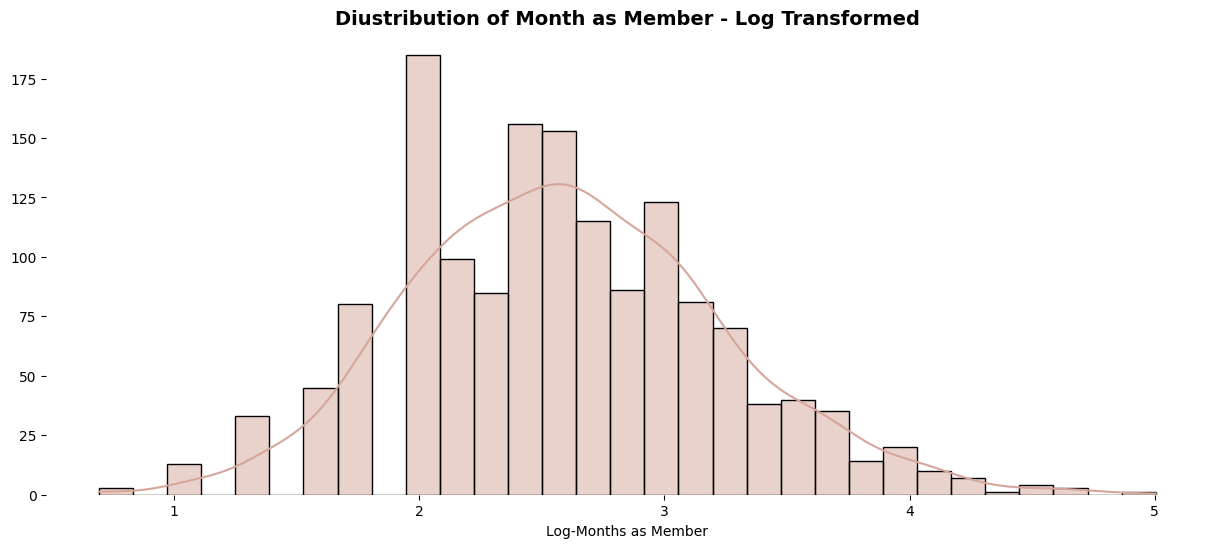

In [30]:
# Due to the right skewed so we will log the values for the distribution to be close normally distributed
plt.figure(figsize=(15, 6))
sns.histplot(data=data, x=np.log1p(data['months_as_member']),kde=True, fill=True,color="#d6a69a")
plt.xlabel('Log-Months as Member')
plt.ylabel("")
plt.title('Diustribution of Month as Member - Log Transformed', size=14, weight="bold")
sns.despine(left=True, bottom=True)
plt.show()

### Data Visualization

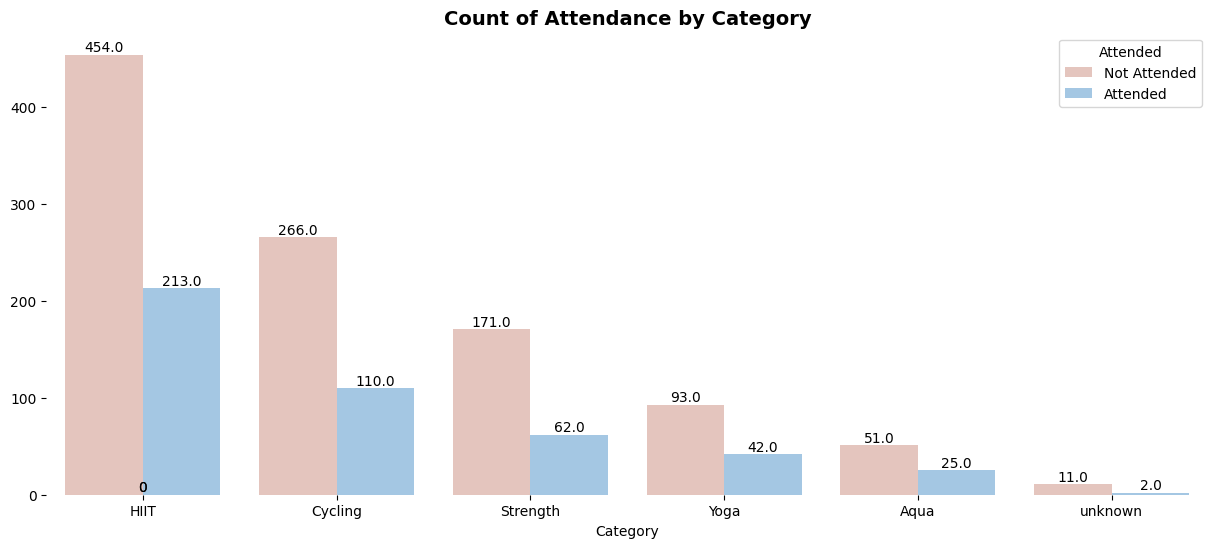

In [31]:
# Calculate the counts for each category
category_counts = data['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']
category_counts = category_counts.sort_values(by='count', ascending=False)
plt.figure(figsize =(15,6))
ax = sns.countplot(data=data, x='category',palette = ["#ebc1b7", "#9ac8ed"], hue='attended', order=category_counts['category'])
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.xlabel('Category')
plt.ylabel("")
plt.title('Count of Attendance by Category', size=14, weight="bold")
plt.legend(title='Attended', labels=['Not Attended', 'Attended'])
sns.despine(left=True, bottom=True)
plt.show()

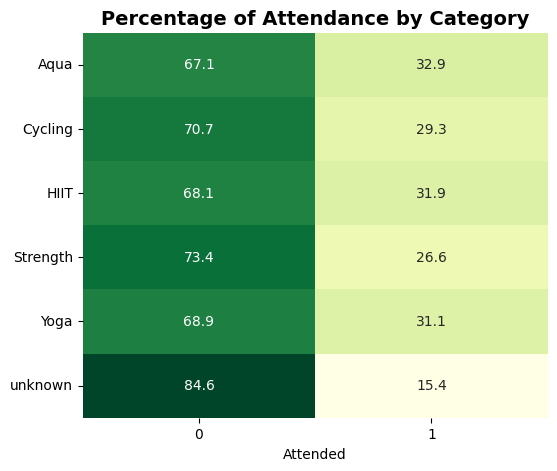

In [32]:
# Create a cross-tabulation with percentage values
cross_tab = pd.crosstab(data['category'], data['attended'], normalize='index') * 100

# Create a heatmap using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cross_tab, annot=True, cmap= "YlGn",fmt='.1f', cbar=False)
plt.xlabel('Attended')
plt.yticks(rotation=0)
plt.ylabel('')
plt.title('Percentage of Attendance by Category', size=14, weight="bold")
plt.show()

### Machine Learning Model Preparation

In [33]:
# Separate features and target
X = data.drop("attended", axis=1) # Features
y = data['attended'] # Target

In [34]:
# Split the dataset into training and testing sets
# X contains the input features, and y contains the target variable

# test_size=0.2 means that 20% of the data will be used for testing
# and the remaining 80% will be used for training

# random_state=42 ensures that the split is reproducible,
# meaning the same rows will be assigned to train and test each time the code runs

# stratify=y preserves the original class distribution of the target variable
# in both the training and testing sets, which is especially important
# for classification problems with imbalanced classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
# Split the numeric and the categorical features
numeric_features = ['months_as_member', 'weight', 'days_before', 'time']
categorical_features = ['day_of_week', 'category']

In [36]:
# Define a preprocessing pipeline for numerical features
# Step 1: Replace missing numerical values with the median of each column
# Step 2: Standardize the numerical features so they have mean = 0 and standard deviation = 1

# Missing values were initially handled during the data cleaning phase.
# Additionally, an imputation step was included in the preprocessing pipeline to ensure consistency between training and testing data.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define a preprocessing pipeline for categorical features
# Step 1: Replace missing categorical values with the most frequent category in each column
# Step 2: Convert categorical variables into numerical format using one-hot encoding
# handle_unknown='ignore' ensures that unseen categories in the test set do not cause errors
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both preprocessing pipelines into a single ColumnTransformer
# Apply the numerical pipeline to numeric_features
# Apply the categorical pipeline to categorical_features
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

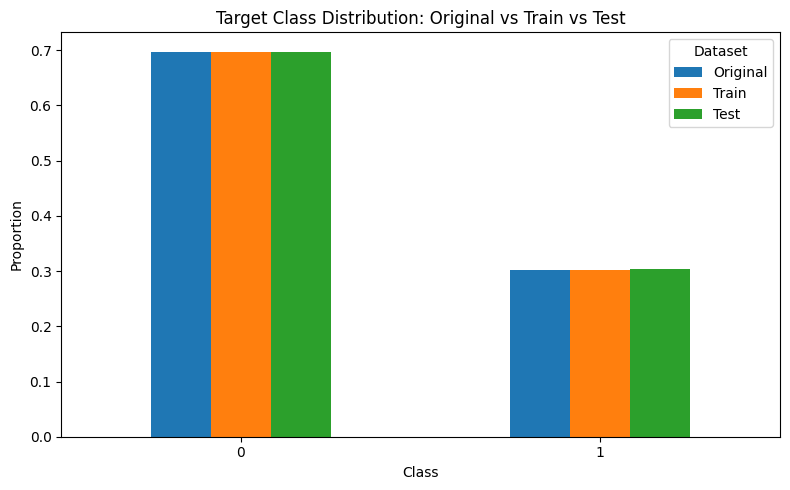

In [37]:
# Check the class distribution in the original target variable,
# as well as in the training and testing sets,
# to confirm that stratified splitting preserved the class proportions
# Create a DataFrame to compare target distribution in original, train, and test sets
target_distribution = pd.DataFrame({
    'Original': y.value_counts(normalize=True).sort_index(),
    'Train': y_train.value_counts(normalize=True).sort_index(),
    'Test': y_test.value_counts(normalize=True).sort_index()
})

# Plot class distribution comparison
target_distribution.plot(kind='bar', figsize=(8,5))
plt.title('Target Class Distribution: Original vs Train vs Test')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

### Apply Models

#### K-Nearest Neighbors

In [38]:
# Loop to test the best k value
# Found that the 5 is best value for k with highest f1_score and accuracy
for k in [3, 5, 7, 9]:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"k={k}, Accuracy={accuracy_score(y_test, preds):.4f}, F1={f1_score(y_test, preds):.4f}")

k=3, Accuracy=0.7500, F1=0.5562
k=5, Accuracy=0.7667, F1=0.5679
k=7, Accuracy=0.7533, F1=0.5316
k=9, Accuracy=0.7533, F1=0.4932


In [39]:
# Build a machine learning pipeline for the K-Nearest Neighbors classifier
# Step 1: Apply the predefined preprocessing pipeline to prepare the data
# Step 2: Train a KNN classifier using 5 nearest neighbors
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Fit the pipeline on the training data
# This applies preprocessing to X_train and then trains the KNN classifier on the transformed data
knn_model.fit(X_train, y_train)

# Generate predictions for the test set
# The same preprocessing steps are automatically applied to X_test before prediction
y_pred_knn = knn_model.predict(X_test)

In [40]:
# Evaluate the KNN model using accuracy, precision, recall, and F1-score
# The classification report provides class-level performance metrics
# Convert KNN classification report into a DataFrame
knn_report = pd.DataFrame(classification_report(y_test, y_pred_knn, output_dict=True)).transpose()

# Format numeric values for better display
knn_report.style.format('{:.2f}')

,precision,recall,f1-score,support
0,0.80,0.88,0.84,209.00
1,0.65,0.51,0.57,91.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.73,0.69,0.70,300.00
weighted avg,0.76,0.77,0.76,300.00


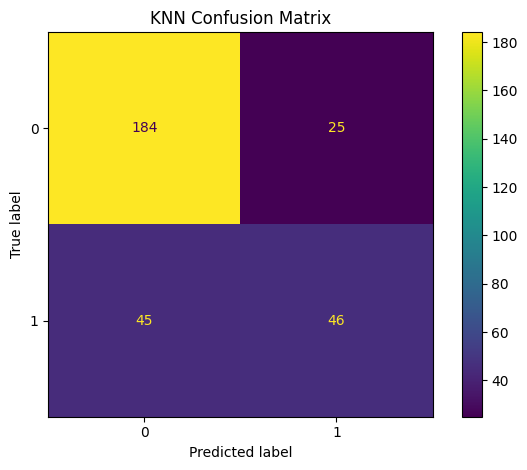

In [41]:
# Confusion Matrix Visualization for the Model Result
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()

#### Decision Tree

In [42]:
# Loop to test the best max depth for the tree root
# Found that the 3 is best value formax depth for the tree root with highest f1_score and accuracy
for d in [3, 5, 7, 10, None]:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"max_depth={d}, Accuracy={accuracy_score(y_test, preds):.4f}, F1={f1_score(y_test, preds):.4f}")

max_depth=3, Accuracy=0.7933, F1=0.6125
max_depth=5, Accuracy=0.7867, F1=0.6000
max_depth=7, Accuracy=0.7800, F1=0.5875
max_depth=10, Accuracy=0.7633, F1=0.5943
max_depth=None, Accuracy=0.6967, F1=0.5134


In [43]:
# Build a machine learning pipeline for the Decision Tree classifier
# Step 1: Apply the predefined preprocessing pipeline to clean and transform the data
# Step 2: Train a Decision Tree classifier on the processed training data
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42))
])

# Fit the pipeline on the training data
# This applies all preprocessing steps to X_train and then trains the Decision Tree model
dt_model.fit(X_train, y_train)

# Generate predictions for the test set
# The same preprocessing transformations are automatically applied to X_test before prediction
y_pred_dt = dt_model.predict(X_test)

In [44]:
# Evaluate the Decision Tree model using accuracy, precision, recall, and F1-score
# The classification report provides class-level performance metrics
# Convert Decision Tree classification report into a DataFrame
dt_report = pd.DataFrame(classification_report(y_test, y_pred_dt, output_dict=True)).transpose()

# Format numeric values for better display
dt_report.style.format('{:.2f}')

,precision,recall,f1-score,support
0,0.82,0.90,0.86,209.00
1,0.71,0.54,0.61,91.00
accuracy,0.79,0.79,0.79,0.79
macro avg,0.76,0.72,0.74,300.00
weighted avg,0.79,0.79,0.78,300.00


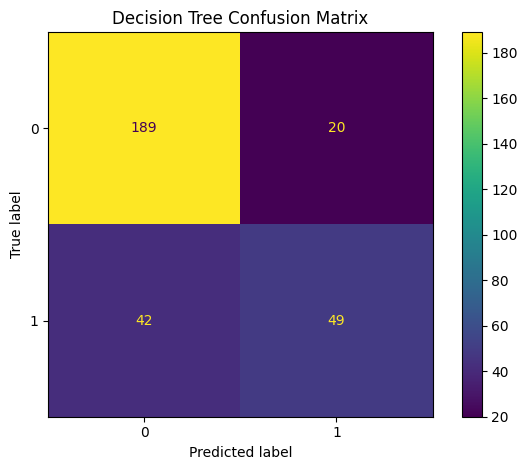

In [45]:
# Confusion Matrix Visualization for the Model Result
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

#### Support Vector Machine

In [46]:
# Build a machine learning pipeline for the Support Vector Machine classifier
# Step 1: Apply the predefined preprocessing pipeline to clean and transform the data
# Step 2: Train an SVM classifier with a linear kernel on the processed training data
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', random_state=42))
])

# Fit the pipeline on the training data
# This applies all preprocessing steps to X_train and then trains the SVM model
svm_model.fit(X_train, y_train)

# Generate predictions for the test set
# The same preprocessing transformations are automatically applied to X_test before prediction
y_pred_svm = svm_model.predict(X_test)

In [47]:
# Evaluate the Support Vector Machines model using accuracy, precision, recall, and F1-score
# The classification report provides class-level performance metrics
# Convert Support Vector Machines classification report into a DataFrame
svm_report = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose()

# Format numeric values for better display
svm_report.style.format('{:.2f}')

,precision,recall,f1-score,support
0,0.80,0.95,0.87,209.00
1,0.79,0.45,0.57,91.00
accuracy,0.80,0.80,0.80,0.80
macro avg,0.79,0.70,0.72,300.00
weighted avg,0.80,0.80,0.78,300.00


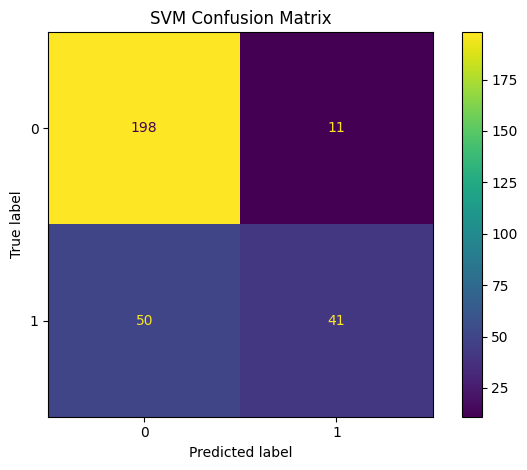

In [48]:
# Confusion Matrix Visualization for the Model Result
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

#### Naive Bayes

In [49]:
# Build a machine learning pipeline for the Naive Bayes "GaussianNB" classifier
# Step 1: Apply the predefined preprocessing pipeline to clean and transform the data
# Step 2: Train an GaussianNB classifier with a linear kernel on the processed training data
nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# Fit the pipeline on the training data
# This applies all preprocessing steps to X_train and then trains the GussianNB model
nb_model.fit(X_train, y_train)

# Generate predictions for the test set
# The same preprocessing transformations are automatically applied to X_test before prediction
y_pred_nb = nb_model.predict(X_test)

In [50]:
# Evaluate the Naive Bayes model using accuracy, precision, recall, and F1-score
# The classification report provides class-level performance metrics
# Convert Naive Bayes classification report into a DataFrame
nb_report = pd.DataFrame(classification_report(y_test, y_pred_nb, output_dict=True)).transpose()

# Format numeric values for better display
nb_report.style.format('{:.2f}')

,precision,recall,f1-score,support
0,0.84,0.86,0.85,209.00
1,0.65,0.62,0.63,91.00
accuracy,0.78,0.78,0.78,0.78
macro avg,0.74,0.74,0.74,300.00
weighted avg,0.78,0.78,0.78,300.00


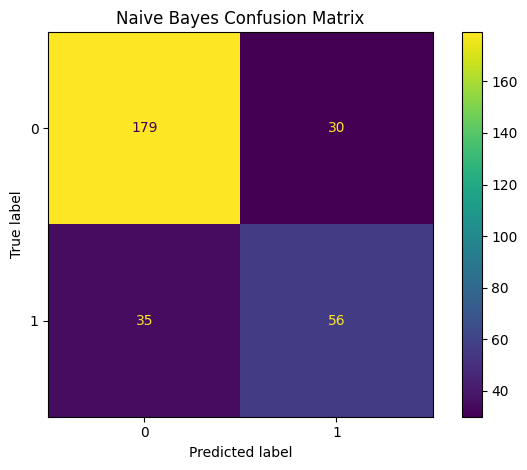

In [51]:
# Confusion Matrix Visualization for the Model Result
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()

### Evaluation

In [52]:
# For visualizing the evaluation score
# Create a function to calculate evaluation metrics for any model
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    }

# Collect evaluation results for all models
results = []
results.append(evaluate_model('KNN', y_test, y_pred_knn))
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))
results.append(evaluate_model('SVM', y_test, y_pred_svm))
results.append(evaluate_model('Naive Bayes', y_test, y_pred_nb))

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Sort models by F1-score from highest to lowest
results_df = results_df.sort_values(by='F1-score', ascending=False)

In [53]:
# Comparison table visualization
results_df.style.background_gradient(cmap='Blues').format({
    'Accuracy': '{:.3f}',
    'Precision': '{:.3f}',
    'Recall': '{:.3f}',
    'F1-score': '{:.3f}'
})

,Model,Accuracy,Precision,Recall,F1-score
3,Naive Bayes,0.783,0.651,0.615,0.633
1,Decision Tree,0.793,0.710,0.538,0.613
2,SVM,0.797,0.788,0.451,0.573
0,KNN,0.767,0.648,0.505,0.568


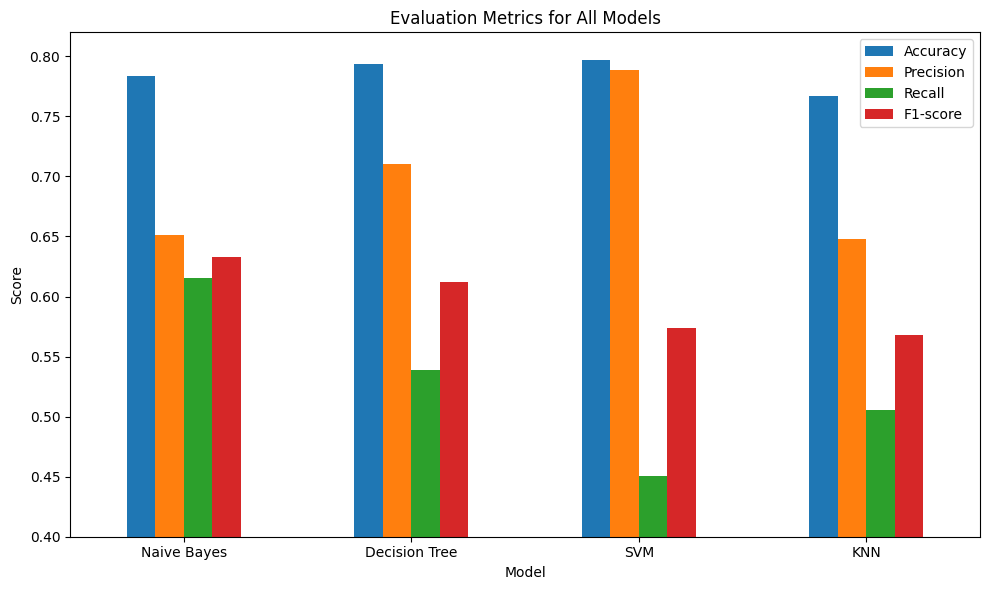

In [54]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Evaluation Metrics for All Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0.4,0.82)
plt.tight_layout()
plt.show()

### Best Model

#### Confusion matrix

In [55]:
# Store predictions for each model
models_predictions = {
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'SVM': y_pred_svm,
    'Naive Bayes': y_pred_nb
}

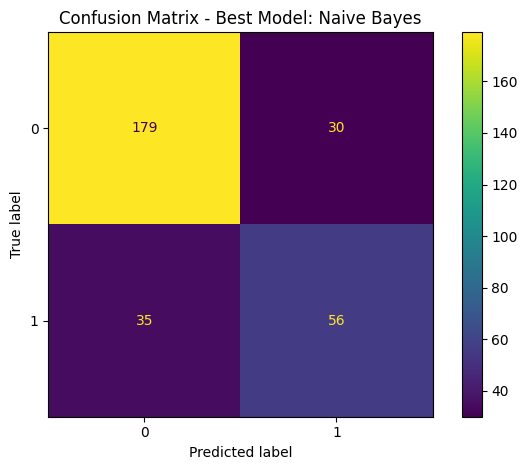

Best Model:
Model        Naive Bayes
Accuracy        0.783333
Precision       0.651163
Recall          0.615385
F1-score        0.632768
Name: 3, dtype: object


In [56]:
# Identify the best model based on F1-score
best_model_name = results_df.iloc[0]['Model']
best_model_pred = models_predictions[best_model_name]

# Plot confusion matrix for the best model
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred)
plt.title(f'Confusion Matrix - Best Model: {best_model_name}')
plt.tight_layout()
plt.show()

print("Best Model:")
print(results_df.iloc[0])